In [91]:
#  ********************************************* MODEL TRAINING **************************************************
# TODO: Create train_models function orchestrating both training pipelines
# TODO: Add progress reporting during training
# TODO: Handle missing model data with informative errors

# TODO: Import pandas, numpy for data handling
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
# TODO: Import scikit-learn models (RandomForestClassifier)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
# TODO: Import LabelEncoder and train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
# TODO: Import pickle for model persistence
import pickle 
import os
import logging
import joblib 

In [2]:
logging.basicConfig(level=logging.INFO)
logger= logging.getLogger(__name__)

In [ ]:
# Importing the risk dataset
r_df = pd.read_csv("C:/Users/USER/Desktop/Vir/Hackathon 2025/Dwarakanath-IND/Project/ml/data/risk_profile_training_dataset.csv")
r_df.head(10)

,age,annual_income,current_savings,investment_horizon_years,number_of_dependents,investment_experience_level,risk_profile
0,56,419417,857876,7,0,Intermediate,Moderate
1,69,1354760,2064122,-4,0,Beginner,Low
2,46,459535,616684,18,2,Intermediate,Moderate
3,32,4064302,5779517,3,0,Intermediate,High
4,60,1312027,1920112,5,0,Advanced,Moderate
5,25,1034725,457164,18,0,Intermediate,High
6,38,1477313,1342474,19,2,Advanced,High
7,56,1165528,1049246,8,2,Intermediate,Low
8,36,1170136,1003953,18,1,Advanced,High
9,40,256418,124880,12,2,Intermediate,Low


In [4]:
#  Non-Null count and data type info for each column of the train dataset
r_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   age                          30000 non-null  int64 
 1   annual_income                30000 non-null  int64 
 2   current_savings              30000 non-null  int64 
 3   investment_horizon_years     30000 non-null  int64 
 4   number_of_dependents         30000 non-null  int64 
 5   investment_experience_level  30000 non-null  object
 6   risk_profile                 30000 non-null  object
dtypes: int64(5), object(2)
memory usage: 1.6+ MB


In [5]:
rf1 = pd.DataFrame()
rf1['Risk Profile']= r_df.risk_profile
rf1.head()

,Risk Profile
0,Moderate
1,Low
2,Moderate
3,High
4,Moderate


In [6]:
# Making target column to numeric "Low = 0, Moderate = 1, High = 2"
rf1['Risk Profile'] = rf1['Risk Profile'].astype(str).replace('Low', 0)
rf1['Risk Profile'] = rf1['Risk Profile'].astype(str).replace('Moderate', 1)
rf1['Risk Profile'] = rf1['Risk Profile'].astype(str).replace('High', 2)
rf1.head()

,Risk Profile
0,1
1,0
2,1
3,2
4,1


In [7]:
rf1 = rf1.astype(int)
rf1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Risk Profile  30000 non-null  int32
dtypes: int32(1)
memory usage: 117.3 KB


In [ ]:
rf2 = rf1.sort_values(by='Risk Profile')

# rf3 = pd.DataFrame()
# rf3['Risk Profile'] = r_df.risk_profile
# # # ds

In [ ]:
rf4 = pd.DataFrame()
rf4['Risk Profile'] = pd.cut(rf2["Risk Profile"], bins=[-1,0,1,2], labels=['Low', 'Moderate', 'High'], 
                                            right=True)
sum(rf4['Risk Profile']=='Low')
sum(rf4['Risk Profile']=='Moderate')
sum(rf4['Risk Profile']=='High')
rf4

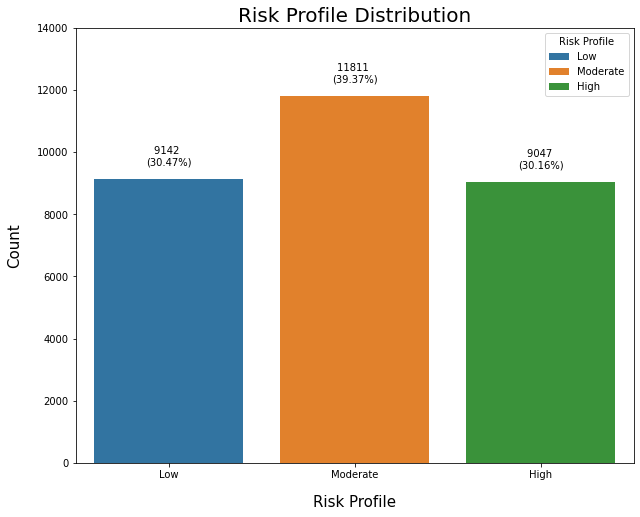

In [74]:
# Risk Target
plt.figure(figsize=(10,8))

rx1 = sns.countplot(x = rf2["Risk Profile"], hue = rf4['Risk Profile'], dodge=False, )
                    # order = r_df['risk_profile'].value_counts(ascending=True).index)

abs_values1 = r_df['risk_profile'].value_counts()
rel_values1 = r_df['risk_profile'].value_counts( normalize=True).values * 100

a = [9142, 11811, 9047]
b = [30.47333333, 39.37, 30.15666667]
lbls1 = [f'{p[0]} \n({round(p[1],2)}%)\n' for p in zip(a, b)]

rx1.bar_label(container = rx1.containers[0], labels = lbls1)
rx1.bar_label(container = rx1.containers[1], labels = lbls1)
rx1.bar_label(container = rx1.containers[2], labels = lbls1)

# plt.legend(labels=['Low', 'Moderate', 'High'], loc="upper right")
plt.title('Risk Profile Distribution', fontsize=20)
plt.xticks(range(3))
rx1.set_xticklabels(['Low', 'Moderate', 'High'])
plt.xlabel('Risk Profile', fontsize=15, labelpad= 15)
plt.ylabel('Count', fontsize=15, labelpad= 15)
plt.ylim(0,14000)
plt.show()

In [79]:
r_df['investment_experience_level'].head()

0    Intermediate
1        Beginner
2    Intermediate
3    Intermediate
4        Advanced
Name: investment_experience_level, dtype: object

In [85]:
# r_df["investment_experience_level"]
rf5 = pd.DataFrame()
rf5['investment_experience_level'] = r_df['investment_experience_level']
# Making target column to numeric "Low = 0, Moderate = 1, High = 2"
rf5['investment_experience_level'] = rf5['investment_experience_level'].astype(str).replace('Beginner', 0)
rf5['investment_experience_level'] = rf5['investment_experience_level'].astype(str).replace('Intermediate', 1)
rf5['investment_experience_level'] = rf5['investment_experience_level'].astype(str).replace('Advanced', 2)
rf6 = rf5.astype(int)

rf7 = rf6.sort_values(by='investment_experience_level')

rf8 = pd.DataFrame()
rf8['investment_experience_level'] = pd.cut(rf7["investment_experience_level"], bins=[-1,0,1,2], labels=['Beginner', 'Intermediate', 'Advanced'], 
                                            right=True)

rf8

,investment_experience_level
16330,Beginner
7628,Beginner
18735,Beginner
23485,Beginner
23484,Beginner
...,...
8943,Advanced
25463,Advanced
5381,Advanced
25473,Advanced


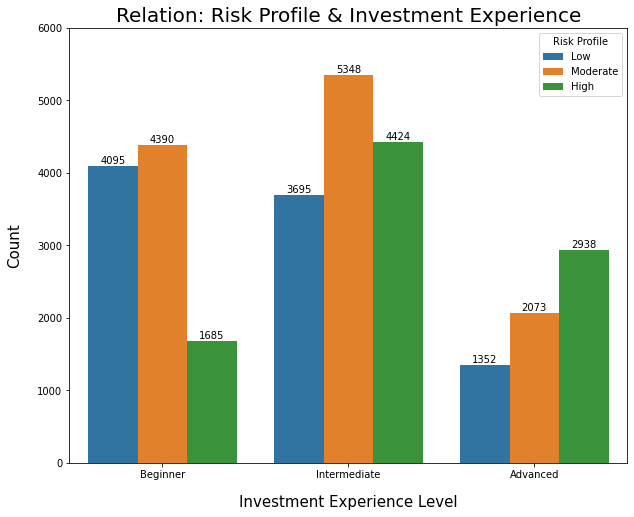

In [90]:
plt.figure(figsize=(10,8))

rx2 = sns.countplot(x = rf8["investment_experience_level"], hue = rf4['Risk Profile'], )
#                 order=ds5['investment_experience_level'] )

for container in rx2.containers:
    rx2.bar_label(container)

# plt.legend(labels=['Low', 'Moderate', 'High'], loc="upper right")
plt.title('Relation: Risk Profile & Investment Experience', fontsize=20)
plt.xlabel('Investment Experience Level', fontsize=15, labelpad= 15)
plt.ylabel('Count', fontsize=15, labelpad= 15)
plt.ylim(0,6000)
plt.show()

In [123]:
# Decision Tree Classifier (Criterion : Entropy )
train_acc1=[]
val_acc1=[]
test_acc1=[]
max_depth=[]
# Calculating the test error
MSE_Train1=[]
MSE_Test1=[]

for i in range(1,11):
    
    risk_df= r_df
    target_col="risk_profile"

    label_encoder = LabelEncoder()
    risk_df["investment_experience_level"]=label_encoder.fit_transform(risk_df["investment_experience_level"])
    feature_cols=["age","annual_income","current_savings","investment_horizon_years","number_of_dependents","investment_experience_level"]

    X=risk_df[feature_cols]
    y=risk_df[target_col]

    y_label_encoder = LabelEncoder()
    y_encoded = y_label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.3, random_state=42)
    # ******************************************    
        
    max_depth.append(i)
    
    # Random Forest Classifier
    random_forest_1 = RandomForestClassifier(criterion='entropy', random_state=42, n_jobs=-1, 
                                             max_depth=i, n_estimators=300, oob_score=True)
    
    # Train the model on the training data
    random_forest_1.fit(X_train,y_train)
    
    # Make predictions on the given data
    y_pred_train = random_forest_1.predict(X_train)
    y_pred_test = random_forest_1.predict(X_test)
    
    train_acc1.append(round(random_forest_1.score(X_train, y_train),2))
    val_acc1.append(round(random_forest_1.score(X_test, y_test),2))

    # Evaluating accuracy, precision, recall and f1-score
    accuracy_decision_tree = accuracy_score(y_test, y_pred_test)
    precision_decision_tree = precision_score(y_test, y_pred_test, average='weighted')
    recall_decision_tree = recall_score(y_test, y_pred_test, average='weighted')
    f1_decision_tree = f1_score(y_test, y_pred_test, average='weighted')
    
    test_acc1.append(round(accuracy_decision_tree,2))
    
    # Calculating mean square error
    mse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    mse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    MSE_Train1.append(mse_train)
    MSE_Test1.append(mse_test)

    print ('Max_Depth:', i)
    print(f'Decision Tree Accuracy: {accuracy_decision_tree:.2f}')
    print(f'Decision Tree Precision: {precision_decision_tree:.2f}')
    print(f'Decision Tree Recall: {recall_decision_tree:.2f}')
    print(f'Decision Tree F1 Score: {f1_decision_tree:.2f}')
    print('--------------------------------------------------------')
    print ('Mean Squared Error (TRAIN):', mse_train)
    print ('Mean Squared Error (TEST):', mse_test)
    print('\n')

C:\Users\USER\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Max_Depth: 1
Decision Tree Accuracy: 0.56
Decision Tree Precision: 0.45
Decision Tree Recall: 0.56
Decision Tree F1 Score: 0.48
--------------------------------------------------------
Mean Squared Error (TRAIN): 1.1563695240667995
Mean Squared Error (TEST): 1.1574397032531183


Max_Depth: 2
Decision Tree Accuracy: 0.68
Decision Tree Precision: 0.73
Decision Tree Recall: 0.68
Decision Tree F1 Score: 0.68
--------------------------------------------------------
Mean Squared Error (TRAIN): 0.9356942927707796
Mean Squared Error (TEST): 0.9364827814754524


Max_Depth: 3
Decision Tree Accuracy: 0.70
Decision Tree Precision: 0.74
Decision Tree Recall: 0.70
Decision Tree F1 Score: 0.70
--------------------------------------------------------
Mean Squared Error (TRAIN): 0.8877741025412136
Mean Squared Error (TEST): 0.9023426301700603


Max_Depth: 4
Decision Tree Accuracy: 0.71
Decision Tree Precision: 0.75
Decision Tree Recall: 0.71
Decision Tree F1 Score: 0.72
--------------------------------

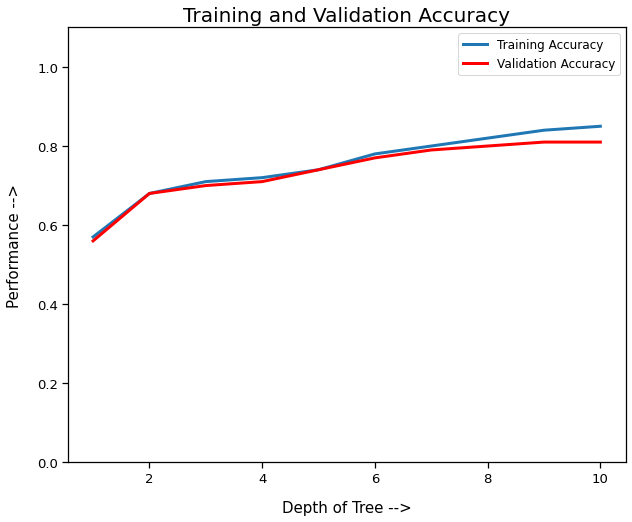

In [124]:
# Graphical representation of train and validation accuracy rates
plt.figure(figsize=(10, 8))
plt.plot(max_depth, train_acc1, label='Training Accuracy',linewidth=3)
plt.plot(max_depth, val_acc1, c='r',label='Validation Accuracy',linewidth=3)
plt.title('Training and Validation Accuracy', fontsize=20)
plt.xlabel('Depth of Tree -->', fontsize=15, labelpad= 15)
plt.ylabel('Performance -->', fontsize=15, labelpad= 15)
plt.ylim(0,1.1)
plt.legend(loc='upper right',fontsize=12)
plt.show()

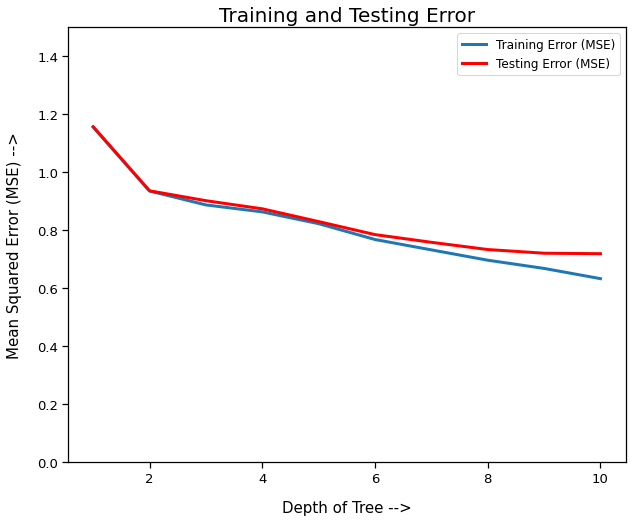

In [125]:
# Graphical representation of train and test error rates
plt.figure(figsize=(10,8))
plt.plot(max_depth,MSE_Train1,label='Training Error (MSE)',linewidth=3)
plt.plot(max_depth,MSE_Test1, c='r',label='Testing Error (MSE)',linewidth=3)
plt.title('Training and Testing Error', fontsize=20)
plt.xlabel('Depth of Tree -->', fontsize=15, labelpad= 15)
plt.ylabel('Mean Squared Error (MSE) -->', fontsize=15, labelpad= 15)
plt.ylim(0,1.5)
plt.legend(loc='upper right',fontsize=12)
plt.show()

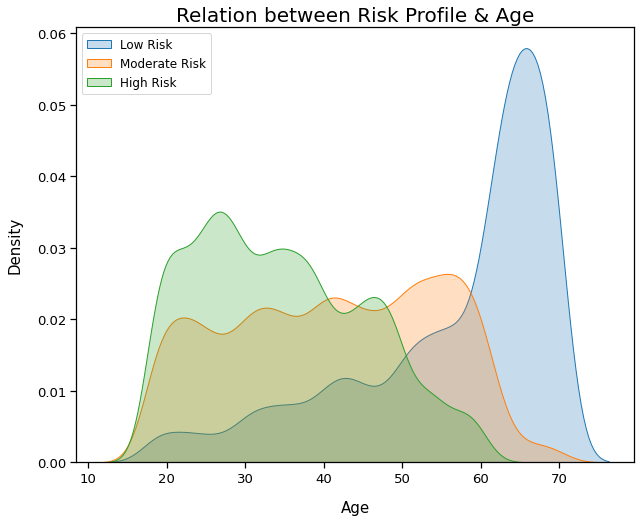

In [156]:
# Density Plot
plt.figure(figsize=(10,8))

sns.kdeplot(risk_df["age"][rf1['Risk Profile'] == 0], shade=True)
sns.kdeplot(risk_df["age"][rf1['Risk Profile'] == 1], shade=True)
sns.kdeplot(risk_df["age"][rf1['Risk Profile'] == 2], shade=True)

plt.legend(['Low Risk', 'Moderate Risk', 'High Risk'], loc='upper left', fontsize=12)
plt.title('Relation between Risk Profile & Age',fontsize=20)
plt.xlabel("Age",fontsize=15, labelpad= 15)
plt.ylabel("Density",fontsize=15, labelpad= 15)
sns.set_context('notebook', font_scale = 1.2)
plt.show()

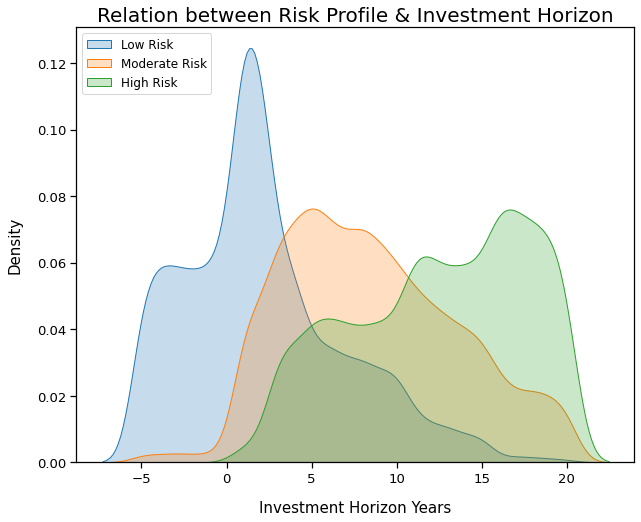

In [157]:
# Density Plot
plt.figure(figsize=(10,8))

sns.kdeplot(risk_df["investment_horizon_years"][rf1['Risk Profile'] == 0], shade=True)
sns.kdeplot(risk_df["investment_horizon_years"][rf1['Risk Profile'] == 1], shade=True)
sns.kdeplot(risk_df["investment_horizon_years"][rf1['Risk Profile'] == 2], shade=True)

plt.legend(['Low Risk', 'Moderate Risk', 'High Risk'], loc='upper left', fontsize=12)
plt.title('Relation between Risk Profile & Investment Horizon',fontsize=20)
plt.xlabel("Investment Horizon Years",fontsize=15, labelpad= 15)
plt.ylabel("Density",fontsize=15, labelpad= 15)
sns.set_context('notebook', font_scale = 1.2)
plt.show()

INFO:__main__:Loading risk profile training data
INFO:__main__:Training RandomForest Model for risk assessment...
INFO:__main__:Risk Model Train Accuracy: 0.90
INFO:__main__:Risk Model Test Accuracy: 0.81
INFO:__main__:Risk Model Test Accuracy (Gradient Boosting): 0.82
INFO:__main__:
 Classification Report (Gradient Boosting): 

              precision    recall  f1-score   support

        High       0.85      0.81      0.83      2716
         Low       0.89      0.85      0.87      2809
    Moderate       0.75      0.81      0.78      3475

    accuracy                           0.82      9000
   macro avg       0.83      0.82      0.83      9000
weighted avg       0.83      0.82      0.82      9000

INFO:__main__:Risk model saved successfully.
INFO:__main__:Risk Profile => Encoders saved successfully


[(0.3096954016737333, 'age'), (0.2593475669755821, 'investment_horizon_years'), (0.14716042332278673, 'annual_income'), (0.13188269074391812, 'investment_experience_level'), (0.10046184036090862, 'current_savings'), (0.05145207692307125, 'number_of_dependents')]


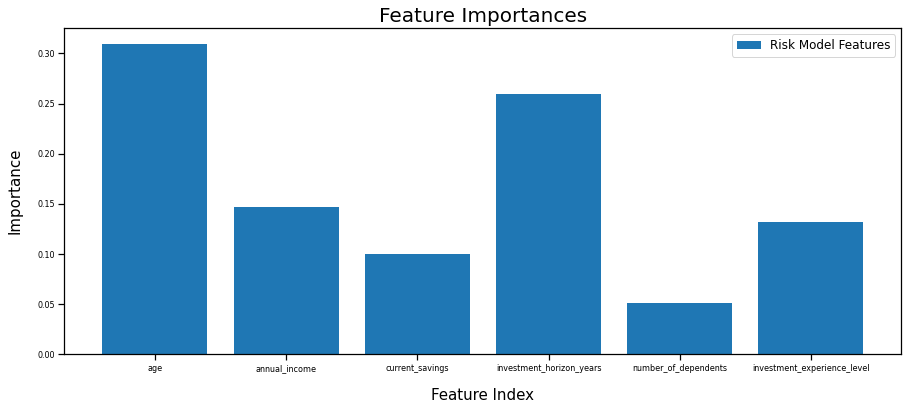

In [127]:
# TODO: Create train_risk_model function:
#   - Load training data from CSV
#   - Prepare features and target variable
#   - Split data into train/test sets
#   - Train RandomForest classifier
#   - Evaluate model performance
#   - Save model and encoders to disk

def train_risk_model():
    try: 
        logger.info("Loading risk profile training data")
        # risk_df=pd.read_csv("data/risk_profile_training_dataset.csv") 
        risk_df = r_df
        if risk_df.empty:
            raise ValueError("Risk profile dataset is empty!")
        
        target_col="risk_profile"

        label_encoder = LabelEncoder()
        risk_df["investment_experience_level"]=label_encoder.fit_transform(risk_df["investment_experience_level"])
        feature_cols=["age","annual_income","current_savings","investment_horizon_years","number_of_dependents","investment_experience_level"]
        
        X=risk_df[feature_cols]
        y=risk_df[target_col]

        y_label_encoder = LabelEncoder()
        y_encoded = y_label_encoder.fit_transform(y)

        X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.3, random_state=42)

        #===================================================================================== Hyperparameter Tuning
        #=========================================================================================== Tuning Done 

        logger.info('Training RandomForest Model for risk assessment...')
        model = RandomForestClassifier(n_estimators= 300, random_state=42,class_weight="balanced",criterion='entropy',
                                        max_depth=15, min_samples_split=5,min_samples_leaf=4, max_features='sqrt',bootstrap=True,max_samples=0.8)
        model.fit(X_train,y_train)

        y_pred_1 = model.predict(X_train)
        acc1 = accuracy_score(y_train, y_pred_1)
        logger.info (f"Risk Model Train Accuracy: {acc1:.2f}")

        y_pred = model.predict(X_test)
        acc= accuracy_score(y_test, y_pred)
        logger.info (f"Risk Model Test Accuracy: {acc:.2f}")
        # logger.info("\n"+ classification_report(y_test,y_pred,target_names=y_label_encoder.classes_))

        # Training a Gradient Boosting Classifier
        gb_model = GradientBoostingClassifier(random_state=1, n_estimators=500, learning_rate=0.1)
        gb_model.fit(X_train, y_train)

        # Making predictions
        y_pred_gb = gb_model.predict(X_test)
        # Evaluating the model
        accuracy_gb = accuracy_score(y_test, y_pred_gb)
        logger.info (f"Risk Model Test Accuracy (Gradient Boosting): {accuracy_gb:.2f}")
        logger.info("\n Classification Report (Gradient Boosting): \n\n" + classification_report(y_test,y_pred_gb,target_names=y_label_encoder.classes_))


#         # Generate learning curve data
#         train_sizes, train_scores, test_scores = learning_curve(
#             model, X_train, y_train, cv=5, n_jobs=-1,
#             train_sizes=np.linspace(0.1, 1.0, 50),  # Vary training set size from 10% to 100%
#             scoring='accuracy'
#         )

#         # Calculate mean and standard deviation for scores
#         train_scores_mean = np.mean(train_scores, axis=1)
#         train_scores_std = np.std(train_scores, axis=1)
#         test_scores_mean = np.mean(test_scores, axis=1)
#         test_scores_std = np.std(test_scores, axis=1)

#         # Plot the learning curve
#         plt.figure(figsize=(10, 6))
#         plt.title("Random Forest Training Curve")
#         plt.xlabel("Training Examples -->", labelpad= 15)
#         plt.ylabel("Accuracy Score (train and validation) -->", labelpad= 15)
#         plt.xlim(0,20000)
#         plt.ylim(0,1.2)
#         # plt.grid()

#         plt.plot(train_sizes, train_scores_mean,'o-',color="r",label="Training Accuracy")
#         plt.plot(train_sizes, test_scores_mean,'o-',color="g",label="Validation Accuracy")
#         plt.legend(loc="upper right")
#         plt.show()

        # saving the model and encoders
        logger.info("Risk model saved successfully.")
        logger.info("Risk Profile => Encoders saved successfully")

        # Plot feature importances
        feature_importances = model.feature_importances_
#         indices = np.argsort(feature_importances)[::-1]

        print(sorted(zip(model.feature_importances_, X.columns), reverse=True))

        plt.figure(figsize=(15, 6))
        plt.bar(range(X.shape[1]), feature_importances, label = "Risk Model Features")
        plt.xticks(range(X.shape[1]), feature_cols, rotation=0, fontsize=8)
        plt.yticks(fontsize=8)
        plt.legend(loc="upper right", fontsize=12)
        plt.title('Feature Importances',fontsize=20)
        plt.xlabel('Feature Index', fontsize=15,labelpad= 15)
        plt.ylabel('Importance', fontsize=15, labelpad= 15)
        plt.show()

    except FileNotFoundError:
        logger.error("Risk profile training data not found.")
    except Exception as e:
        logger.error(f"Error Training risk model: {e}")
    

train_risk_model()

In [ ]:
# ****************************************** Risk END ***************************************** #

In [129]:
# Importing the goal dataset
g_df = pd.read_csv("C:/Users/USER/Desktop/Vir/Hackathon 2025/Dwarakanath-IND/Project/ml/data/goal_success_training_dataset.csv")
g_df.head(10)

,age,annual_income,current_savings,target_goal_amount,investment_horizon_years,number_of_dependents,investment_experience_level,goal_success
0,22,1287616,216898,1543392,2,0,Beginner,Unlikely
1,61,358744,698678,1781208,4,0,Advanced,Unlikely
2,57,247674,254216,1522405,8,0,Intermediate,Unlikely
3,70,876223,1608302,9103047,-5,0,Intermediate,Unlikely
4,70,509574,1859367,8912894,-5,2,Intermediate,Unlikely
5,54,1490738,4601187,23890204,11,2,Advanced,Unlikely
6,52,2042647,1441012,6132965,13,3,Advanced,Likely
7,61,1342299,1727766,12300547,4,0,Beginner,Unlikely
8,49,970842,2322806,8339916,6,0,Intermediate,Unlikely
9,20,3367248,2981476,5031773,19,2,Beginner,Likely


In [130]:
#  Non-Null count and data type info for each column of the train dataset
g_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   age                          30000 non-null  int64 
 1   annual_income                30000 non-null  int64 
 2   current_savings              30000 non-null  int64 
 3   target_goal_amount           30000 non-null  int64 
 4   investment_horizon_years     30000 non-null  int64 
 5   number_of_dependents         30000 non-null  int64 
 6   investment_experience_level  30000 non-null  object
 7   goal_success                 30000 non-null  object
dtypes: int64(6), object(2)
memory usage: 1.8+ MB


In [132]:
gf1 = pd.DataFrame()
gf1['Goal Success']= g_df.goal_success 
gf1.head(10)

,Goal Success
0,Unlikely
1,Unlikely
2,Unlikely
3,Unlikely
4,Unlikely
5,Unlikely
6,Likely
7,Unlikely
8,Unlikely
9,Likely


In [134]:
# Making target column to numeric "Low = 0, Moderate = 1, High = 2"
gf1['Goal Success'] = gf1['Goal Success'].astype(str).replace('Unlikely', 0)
gf1['Goal Success'] = gf1['Goal Success'].astype(str).replace('Likely', 1)
gf1['Goal Success'] = gf1['Goal Success'].astype(str).replace('Moderate', 2)
gf1.head(10)

,Goal Success
0,0
1,0
2,0
3,0
4,0
5,0
6,1
7,0
8,0
9,1


In [135]:
gf1 = gf1.astype(int)
gf1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Goal Success  30000 non-null  int32
dtypes: int32(1)
memory usage: 117.3 KB


In [136]:
gf2 = gf1.sort_values(by='Goal Success')

In [139]:
gf4 = pd.DataFrame()
gf4['Goal Success'] = pd.cut(gf2["Goal Success"], bins=[-1,0,1,2], labels=['Unlikely', 'Likely', 'Moderate'], 
                                            right=True)
sum(gf4['Goal Success']=='Unlikely')
sum(gf4['Goal Success']=='Likely')
sum(gf4['Goal Success']=='Moderate')
# gf4

5667

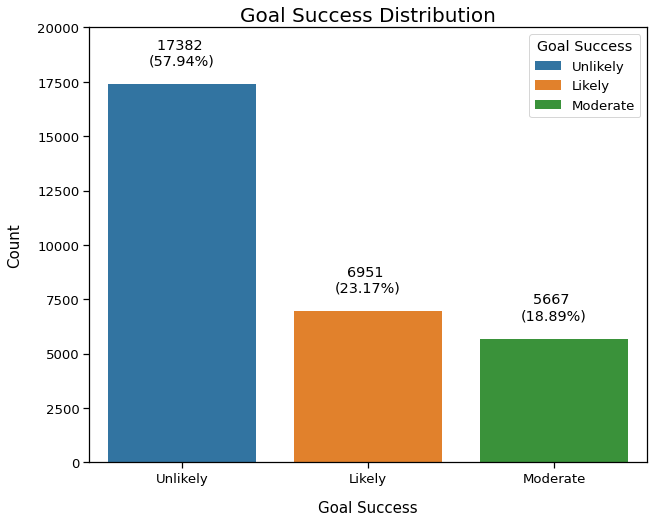

In [143]:
# Goal Target
plt.figure(figsize=(10,8))

gx1 = sns.countplot(x = g_df['goal_success'], hue = gf4['Goal Success'], dodge=False, )
                    # order = r_df['risk_profile'].value_counts(ascending=True).index)

abs_values2 = g_df['goal_success'].value_counts()
rel_values2 = g_df['goal_success'].value_counts( normalize=True).values * 100

a = [17382, 6951, 5667]
b = [57.94, 23.17, 18.89]
lbls2 = [f'{p[0]} \n({round(p[1],2)}%)\n' for p in zip(a, b)]

gx1.bar_label(container = gx1.containers[0], labels = lbls2)
gx1.bar_label(container = gx1.containers[1], labels = lbls2)
gx1.bar_label(container = gx1.containers[2], labels = lbls2)

# plt.legend(labels=['Low', 'Moderate', 'High'], loc="upper right")
plt.title('Goal Success Distribution', fontsize=20)
plt.xticks(range(3))
rx1.set_xticklabels(['Unlikely', 'Likely', 'Moderate'])
plt.xlabel('Goal Success', fontsize=15, labelpad= 15)
plt.ylabel('Count', fontsize=15, labelpad= 15)
plt.ylim(0,20000)
plt.show()

In [144]:
gf5 = pd.DataFrame()
gf5['investment_experience_level'] = g_df['investment_experience_level']
# Making target column to numeric "Low = 0, Moderate = 1, High = 2"
gf5['investment_experience_level'] = gf5['investment_experience_level'].astype(str).replace('Beginner', 0)
gf5['investment_experience_level'] = gf5['investment_experience_level'].astype(str).replace('Intermediate', 1)
gf5['investment_experience_level'] = gf5['investment_experience_level'].astype(str).replace('Advanced', 2)
gf6 = gf5.astype(int)

gf7 = gf6.sort_values(by='investment_experience_level')

gf8 = pd.DataFrame()
gf8['investment_experience_level'] = pd.cut(gf7["investment_experience_level"], bins=[-1,0,1,2], labels=['Beginner', 'Intermediate', 'Advanced'], 
                                            right=True)

gf8

,investment_experience_level
0,Beginner
15094,Beginner
15095,Beginner
15096,Beginner
15101,Beginner
...,...
13114,Advanced
23014,Advanced
23013,Advanced
13122,Advanced


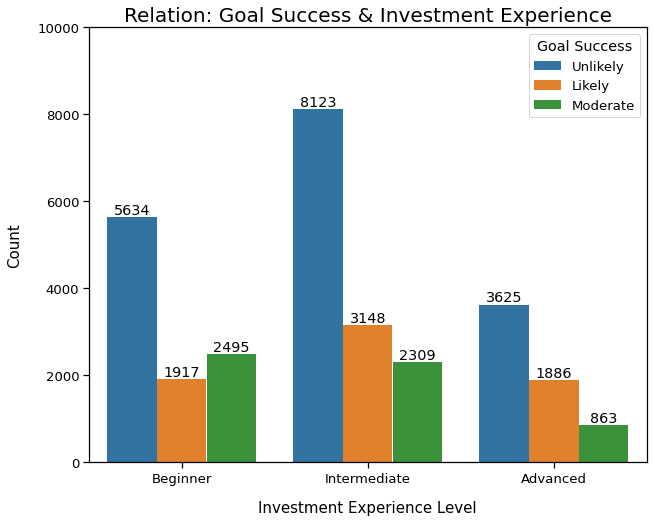

In [147]:
plt.figure(figsize=(10,8))

gx2 = sns.countplot(x = gf8["investment_experience_level"], hue = gf4['Goal Success'], )
#                 order=ds5['investment_experience_level'] )

for container in gx2.containers:
    gx2.bar_label(container)

# plt.legend(labels=['Low', 'Moderate', 'High'], loc="upper right")
plt.title('Relation: Goal Success & Investment Experience', fontsize=20)
plt.xlabel('Investment Experience Level', fontsize=15, labelpad= 15)
plt.ylabel('Count', fontsize=15, labelpad= 15)
plt.ylim(0,10000)
plt.show()

In [148]:
# Decision Tree Classifier (Criterion : Entropy )
train_acc2=[]
val_acc2=[]
test_acc2=[]
max_depth=[]
# Calculating the test error
MSE_Train2=[]
MSE_Test2=[]

for i in range(1,11):
    
    goal_df=g_df

    target_col="goal_success"

    label_encoder = LabelEncoder()
    goal_df["investment_experience_level"]=label_encoder.fit_transform(goal_df["investment_experience_level"])
    feature_cols=["age","annual_income","current_savings","target_goal_amount","investment_horizon_years","number_of_dependents","investment_experience_level"]

    X=goal_df[feature_cols]
    y=goal_df[target_col]

    y_label_encoder = LabelEncoder()
    y_encoded = y_label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.3, random_state=42)
    # ******************************************    
        
    max_depth.append(i)
    
    # Random Forest Classifier
    random_forest_2 = RandomForestClassifier(criterion='entropy', random_state=42, n_jobs=-1, max_depth=i, 
                                             n_estimators=300, oob_score=True)
    
    # Train the model on the training data
    random_forest_2.fit(X_train,y_train)
    
    # Make predictions on the given data
    y_pred_train = random_forest_2.predict(X_train)
    y_pred_test = random_forest_2.predict(X_test)
    
    train_acc2.append(round(random_forest_2.score(X_train, y_train),2))
    val_acc2.append(round(random_forest_2.score(X_test, y_test),2))

    # Evaluating accuracy, precision, recall and f1-score
    accuracy_decision_tree1 = accuracy_score(y_test, y_pred_test)
    precision_decision_tree1 = precision_score(y_test, y_pred_test, average='weighted')
    recall_decision_tree1 = recall_score(y_test, y_pred_test, average='weighted')
    f1_decision_tree1 = f1_score(y_test, y_pred_test, average='weighted')
    
    test_acc2.append(round(accuracy_decision_tree1,2))
    
    # Calculating mean square error
    mse_train1 = np.sqrt(mean_squared_error(y_train, y_pred_train))
    mse_test1 = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    MSE_Train2.append(mse_train1)
    MSE_Test2.append(mse_test1)

    print ('Max_Depth:', i)
    print(f'Decision Tree Accuracy: {accuracy_decision_tree1:.2f}')
    print(f'Decision Tree Precision: {precision_decision_tree1:.2f}')
    print(f'Decision Tree Recall: {recall_decision_tree1:.2f}')
    print(f'Decision Tree F1 Score: {f1_decision_tree1:.2f}')
    print('--------------------------------------------------------')
    print ('Mean Squared Error (TRAIN):', mse_train1)
    print ('Mean Squared Error (TEST):', mse_test1)
    print('\n')

C:\Users\USER\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Max_Depth: 1
Decision Tree Accuracy: 0.58
Decision Tree Precision: 0.33
Decision Tree Recall: 0.58
Decision Tree F1 Score: 0.42
--------------------------------------------------------
Mean Squared Error (TRAIN): 1.0530906893520615
Mean Squared Error (TEST): 1.0636415436289302




C:\Users\USER\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Max_Depth: 2
Decision Tree Accuracy: 0.75
Decision Tree Precision: 0.63
Decision Tree Recall: 0.75
Decision Tree F1 Score: 0.68
--------------------------------------------------------
Mean Squared Error (TRAIN): 0.6899620417440506
Mean Squared Error (TEST): 0.6737952211169207


Max_Depth: 3
Decision Tree Accuracy: 0.75
Decision Tree Precision: 0.62
Decision Tree Recall: 0.75
Decision Tree F1 Score: 0.68
--------------------------------------------------------
Mean Squared Error (TRAIN): 0.6854612628421412
Mean Squared Error (TEST): 0.6702404212088542


Max_Depth: 4
Decision Tree Accuracy: 0.76
Decision Tree Precision: 0.72
Decision Tree Recall: 0.76
Decision Tree F1 Score: 0.71
--------------------------------------------------------
Mean Squared Error (TRAIN): 0.6348978170503015
Mean Squared Error (TEST): 0.6252999280345393


Max_Depth: 5
Decision Tree Accuracy: 0.78
Decision Tree Precision: 0.74
Decision Tree Recall: 0.78
Decision Tree F1 Score: 0.73
--------------------------------

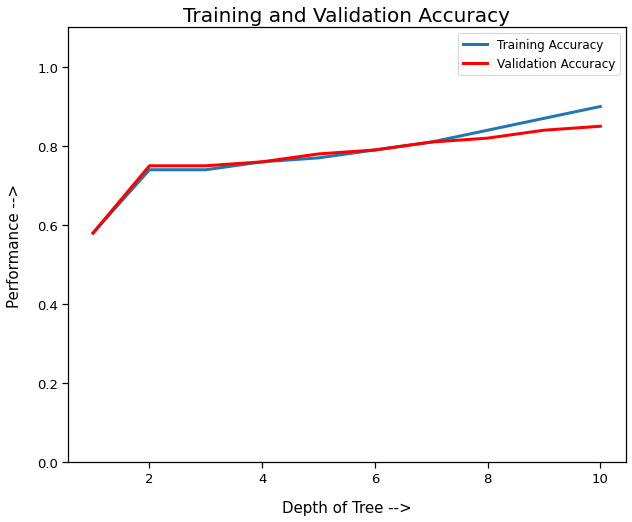

In [149]:
# Graphical representation of train and validation accuracy rates
plt.figure(figsize=(10, 8))
plt.plot(max_depth, train_acc2, label='Training Accuracy',linewidth=3)
plt.plot(max_depth, val_acc2, c='r',label='Validation Accuracy',linewidth=3)
plt.title('Training and Validation Accuracy', fontsize=20)
plt.xlabel('Depth of Tree -->', fontsize=15, labelpad= 15)
plt.ylabel('Performance -->', fontsize=15, labelpad= 15)
plt.ylim(0,1.1)
plt.legend(loc='upper right',fontsize=12)
plt.show()

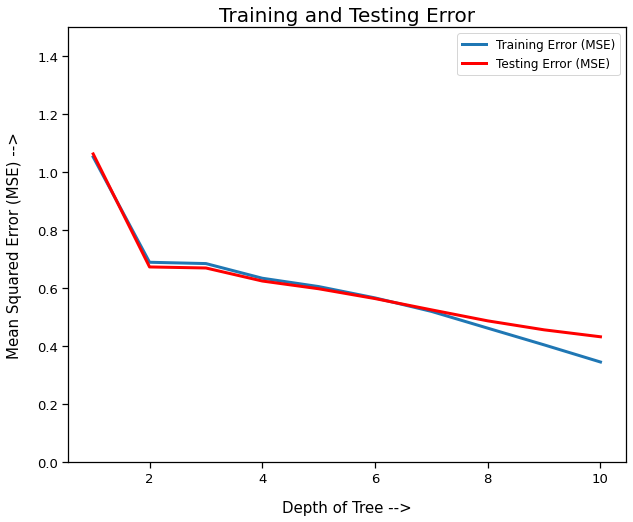

In [150]:
# Graphical representation of train and test error rates
plt.figure(figsize=(10,8))
plt.plot(max_depth,MSE_Train2,label='Training Error (MSE)',linewidth=3)
plt.plot(max_depth,MSE_Test2, c='r',label='Testing Error (MSE)',linewidth=3)
plt.title('Training and Testing Error', fontsize=20)
plt.xlabel('Depth of Tree -->', fontsize=15, labelpad= 15)
plt.ylabel('Mean Squared Error (MSE) -->', fontsize=15, labelpad= 15)
plt.ylim(0,1.5)
plt.legend(loc='upper right',fontsize=12)
plt.show()

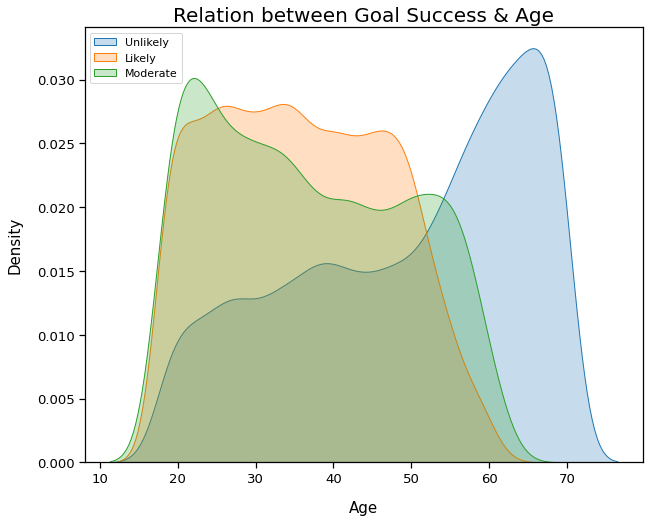

In [158]:
# Density Plot
plt.figure(figsize=(10,8))

sns.kdeplot(goal_df["age"][gf1['Goal Success'] == 0], shade=True)
sns.kdeplot(goal_df["age"][gf1['Goal Success'] == 1], shade=True)
sns.kdeplot(goal_df["age"][gf1['Goal Success'] == 2], shade=True)

plt.legend(['Unlikely', 'Likely', 'Moderate'], loc='upper left', fontsize=11)
plt.title('Relation between Goal Success & Age',fontsize=20)
plt.xlabel("Age",fontsize=15, labelpad= 15)
plt.ylabel("Density",fontsize=15, labelpad= 15)
sns.set_context('notebook', font_scale = 1.2)
plt.show()

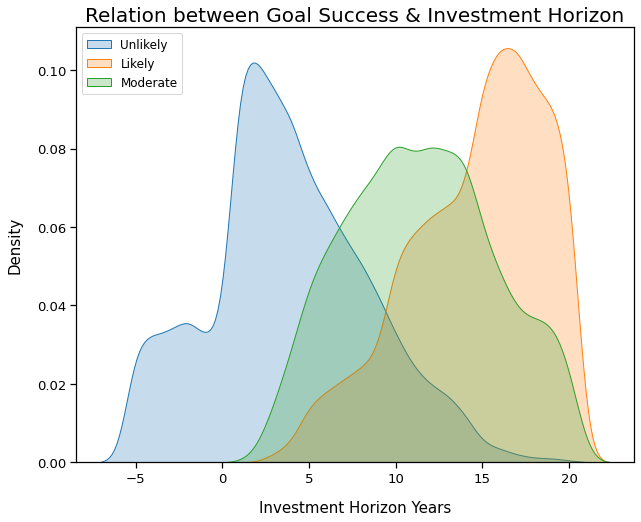

In [159]:
# Density Plot
plt.figure(figsize=(10,8))

sns.kdeplot(goal_df["investment_horizon_years"][gf1['Goal Success']  == 0], shade=True)
sns.kdeplot(goal_df["investment_horizon_years"][gf1['Goal Success']  == 1], shade=True)
sns.kdeplot(goal_df["investment_horizon_years"][gf1['Goal Success']  == 2], shade=True)

plt.legend(['Unlikely', 'Likely', 'Moderate'], loc='upper left', fontsize=12)
plt.title('Relation between Goal Success & Investment Horizon',fontsize=20)
plt.xlabel("Investment Horizon Years",fontsize=15, labelpad= 15)
plt.ylabel("Density",fontsize=15, labelpad= 15)
sns.set_context('notebook', font_scale = 1.2)
plt.show()

INFO:__main__:Loading goal success training data...
INFO:__main__:Goal Success Model Train Accuracy: 0.94
INFO:__main__:Goal Success Model Test Accuracy: 0.86
INFO:__main__:Goal Success Model Test Accuracy (Gradient Boosting): 0.89
INFO:__main__:
 Classification Report (Gradient Boosting): 

              precision    recall  f1-score   support

      Likely       0.86      0.86      0.86      2130
    Moderate       0.71      0.67      0.69      1662
    Unlikely       0.95      0.97      0.96      5208

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000

INFO:__main__:Goal Success model saved successfully.
INFO:__main__:Goal Success => Target Encoder saved successfully


[(0.38181743665000806, 'investment_horizon_years'), (0.1891267576721916, 'target_goal_amount'), (0.1332575262537553, 'age'), (0.1263402054571061, 'annual_income'), (0.11109062343359537, 'current_savings'), (0.03192380828806812, 'investment_experience_level'), (0.02644364224527542, 'number_of_dependents')]


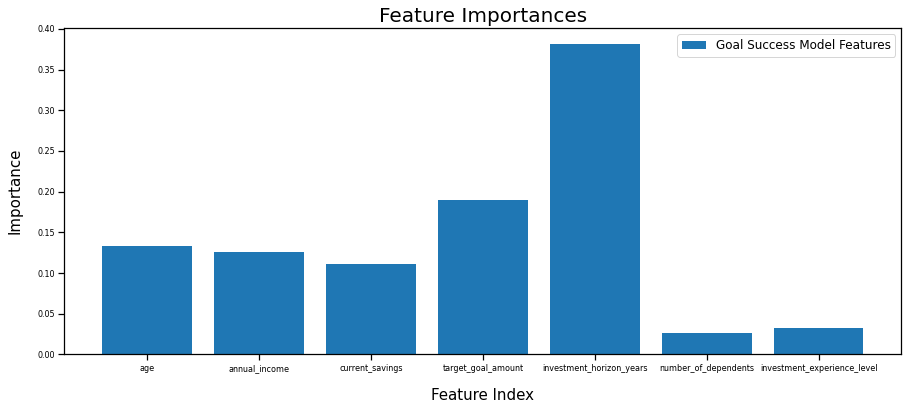

In [155]:
# TODO: Create train_goal_model function:
#   - Load training data
#   - Prepare features for goal success prediction
#   - Train classifier
#   - Evaluate performance
#   - Save model and encoders

def train_goal_model():
    try:
        logger.info("Loading goal success training data...")
        # goal_df=pd.read_csv("data/goal_success_training_dataset.csv")
        goal_df=g_df
        if goal_df.empty:
            raise ValueError("Goal success dataset is empty!")

        target_col="goal_success"
        
        label_encoder = LabelEncoder()
        goal_df["investment_experience_level"]=label_encoder.fit_transform(goal_df["investment_experience_level"])
        feature_cols=["age","annual_income","current_savings","target_goal_amount","investment_horizon_years","number_of_dependents","investment_experience_level"]
        
        X=goal_df[feature_cols]
        y=goal_df[target_col]

        y_label_encoder = LabelEncoder()
        y_encoded = y_label_encoder.fit_transform(y)

        X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.3, random_state=42)

        model = RandomForestClassifier(n_estimators= 300, random_state=42,class_weight="balanced",criterion='entropy',
                                       max_depth=15, min_samples_split=5,min_samples_leaf=4, max_features='sqrt',
                                       bootstrap=True,max_samples=0.8)
        model.fit(X_train,y_train)

        y_pred_1 = model.predict(X_train)
        acc1 = accuracy_score(y_train, y_pred_1)
        logger.info (f"Goal Success Model Train Accuracy: {acc1:.2f}")

        y_pred = model.predict(X_test)
        acc= accuracy_score(y_test, y_pred)
        logger.info (f"Goal Success Model Test Accuracy: {acc:.2f}")
        # logger.info("\n"+ classification_report(y_test,y_pred,target_names=y_label_encoder.classes_))

        # Training a Gradient Boosting Classifier
        gb_model = GradientBoostingClassifier(random_state=1, n_estimators=500, learning_rate=0.1)
        gb_model.fit(X_train, y_train)

        # Making predictions
        y_pred_gb = gb_model.predict(X_test)
        # Evaluating the model
        accuracy_gb = accuracy_score(y_test, y_pred_gb)
        logger.info (f"Goal Success Model Test Accuracy (Gradient Boosting): {accuracy_gb:.2f}")
        logger.info("\n Classification Report (Gradient Boosting): \n\n" + classification_report(y_test,y_pred_gb,target_names=y_label_encoder.classes_))

#         # Generate learning curve data
#         train_sizes, train_scores, test_scores = learning_curve(
#             model, X_train, y_train, cv=5, n_jobs=-1,
#             train_sizes=np.linspace(0.1, 1.0, 100),  # Vary training set size from 10% to 100%
#             scoring='accuracy'
#         )

#         # Calculate mean and standard deviation for scores
#         train_scores_mean = np.mean(train_scores, axis=1)
#         train_scores_std = np.std(train_scores, axis=1)
#         test_scores_mean = np.mean(test_scores, axis=1)
#         test_scores_std = np.std(test_scores, axis=1)

#         # Plot the learning curve
#         plt.figure(figsize=(10, 6))
#         plt.title("Random Forest Training Curve")
#         plt.xlabel("Training Examples -->", labelpad= 15)
#         plt.ylabel("Accuracy Score (train and validation) -->", labelpad= 15)
#         plt.xlim(0,20000)
#         plt.ylim(0,1.2)
#         # plt.grid()

#         plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
#                         train_scores_mean + train_scores_std, alpha=0.1,
#                         color="r")
#         plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
#                         test_scores_mean + test_scores_std, alpha=0.1,
#                         color="g")
#         plt.plot(train_sizes, train_scores_mean,'+-',color="r",label="Training Accuracy")
#         plt.plot(train_sizes, test_scores_mean,'*-',color="g",label="Validation Accuracy")
#         plt.legend(loc="upper right")
#         plt.show()

        # saving the model and encoders
        logger.info("Goal Success model saved successfully.")
        logger.info("Goal Success => Target Encoder saved successfully")
        
        
        # Plot feature importances
        feature_importances = model.feature_importances_
#         indices = np.argsort(feature_importances)[::-1]

#         print(zip(X.columns, model.feature_importances_))
        print(sorted(zip(model.feature_importances_, X.columns), reverse=True))

        
        plt.figure(figsize=(15, 6))
        plt.bar(range(X.shape[1]), feature_importances, label ="Goal Success Model Features")
        plt.xticks(range(X.shape[1]), feature_cols, rotation=0, fontsize=8)
        plt.yticks(fontsize=8)
        plt.legend(loc="upper right", fontsize=12)
        plt.title('Feature Importances',fontsize=20)
        plt.xlabel('Feature Index', fontsize=15,labelpad= 15)
        plt.ylabel('Importance', fontsize=15, labelpad= 15)
        plt.show()


    except FileNotFoundError:
        logger.error("Goal success training data not found.")
    except Exception as e:
        logger.error(f"Error Training goal success model: {e}")



train_goal_model()

In [ ]:
# ****************************************** Goal END ***************************************** #